In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os 
from pathlib import Path
import torch 

import m2aia as m2
from MSIAutoEncoderWrapper import IMSPyTorchDataset, IMSAutoEncoder 
from MSIAutoEncoderWrapper.utils.Binners import LinearBinning, NotEmptyInverseBinner, TopPeaksInverseBinner

# seting global dir
cwd=Path.cwd()
if cwd.parent.name == "notebooks":
    # os.chdir(cwd.parent.parent) 
    os.chdir(cwd.parent.parent) 
os.getcwd()

'/home/maxi7524/repositories/pym2aia_test'

In [ ]:
PATH_DATA = Path('data') / 'bladder_data'

In [ ]:
# data loading 
PATH_real_data = PATH_DATA / 'bladder_data' / 'mouse_urinary_bladder.imzML'
print(PATH_real_data.exists())

# load data - IMPORTANT (NEED TO PASS STR)
I = m2.ImzMLReader(
    str(PATH_real_data),
    # We assume tic normalization
    normalization=m2.m2NormalizationTIC
)

True
!Wed May  6 19:23:09 2026 
5.588! WARNING: No pixel size found, set x and y spacing to 50 microns!
[6.812] Initialization of the Normalization images took: 4.4637 Average(1 runs):4.4637s
!9.317! WARNING: Processed profile spectrum is not fully supported! Check the ImzML file.
[10.152] [imzML]: data/bladder_data/bladder_data/mouse_urinary_bladder.imzML
	[pixel size (mm)]: 0.050000x0.050000x0.010000
	[image dimension]: 260x134x1
	[num spectra]: 34840
	[spec. type]: ProcessedProfile
	[mass range]: 400.259620 to 999.795899 with #1500 measurements
	[normalization]: TIC


In [5]:
# instantiation model|
model_path = PATH_DATA / 'ReverseNetwork' / 'model_new_architecture'
## new model takes much more data
model = IMSAutoEncoder(path=model_path, epochs=10,batch_size=128)

Model will be loaded on cuda


In [9]:
# create new model

# creating dataset
# TODO this name is misleading - it is formally dataset
xs_res = I.GetSpacing()[2]
## i round values to max spacing to obtain 'nice' numbers, and i want to consider first and last numbers
xs_min = np.round(I.GetXAxis()[0] - xs_res, int(- np.log10(xs_res)))
xs_max = np.round(I.GetXAxis()[-1] + xs_res, int(- np.log10(xs_res)))
Binner = LinearBinning(
    xs_min=np.round(I.GetXAxis()[0]),
    xs_max=np.ceil(I.GetXAxis()[-1]),
    xs_res=xs_res,
)
# REMARKS - it can be unusable if model is not decoding well enough
# InverseBinner = NotEmptyInverseBinner(Binner)
InverseBinner = TopPeaksInverseBinner(Binner, max_bins=1500)

dataset = IMSPyTorchDataset(m2aia_img=I, Binner=Binner)

In [ ]:
# model imports
## architectures
from MSIAutoEncoderWrapper.architectures import ContrastiveAutoencoderMax_InverseDim
## criterions
from MSIAutoEncoderWrapper.criterions import ContrastiveCriterion


# Setting model
## Dataset
model.SetIMSDataset(IMSDataset=dataset)

InverseBinner = TopPeaksInverseBinner(Binner, max_bins=1500)
model.SetInverseBinner(InverseBinner)

## Architecture
### remark: it can ~ 1 min because of dimensions calculations based on IMS
model.SetArchitecture(
    ArchitectureClass=ContrastiveAutoencoderMax_InverseDim,
    latent_dim=300,
    user_hyperparameters=None # it will adjust them automatically
)
## Criterion
### REMARK: we can change it between `fit`
model.SetCriterion(
    CriterionClass=ContrastiveCriterion,
    crit_params={
        'temperature': 2,
        'max_peaks_per_spectrum': 2} 

)

In [5]:
model._hyperparameters

{'input_dim': 60001,
 'latent_dim': 300,
 'channels': [1, 64, 32, 16, 8],
 'kernels': [25, 7, 5, 3],
 'strides': [3, 4, 4, 3]}

In [ ]:
# # ~3 min for 2 peaks 
# model.fit()

Building noise bank (max 2 peaks per spectrum)...
PeakBank created with 69680 total noise samples.

--- Epoch 1/10 ---
[  5%] 1792/34840 pixels processed | Loss: 0.4383 | ETA: 27.5 min
[ 10%] 3584/34840 pixels processed | Loss: 0.1760 | ETA: 26.1 min
[ 15%] 5376/34840 pixels processed | Loss: 0.1156 | ETA: 24.2 min
[ 21%] 7168/34840 pixels processed | Loss: 0.0990 | ETA: 22.6 min
[ 26%] 8960/34840 pixels processed | Loss: 0.0992 | ETA: 20.9 min
[ 31%] 10752/34840 pixels processed | Loss: 0.0937 | ETA: 19.6 min
[ 36%] 12544/34840 pixels processed | Loss: 0.0898 | ETA: 18.2 min
[ 41%] 14336/34840 pixels processed | Loss: 0.0899 | ETA: 17.0 min
[ 46%] 16128/34840 pixels processed | Loss: 0.0874 | ETA: 15.5 min
[ 51%] 17920/34840 pixels processed | Loss: 0.0849 | ETA: 13.9 min
[ 57%] 19712/34840 pixels processed | Loss: 0.0838 | ETA: 12.5 min
[ 62%] 21504/34840 pixels processed | Loss: 0.0825 | ETA: 11.0 min
[ 67%] 23296/34840 pixels processed | Loss: 0.0849 | ETA: 9.6 min
[ 72%] 25088/348

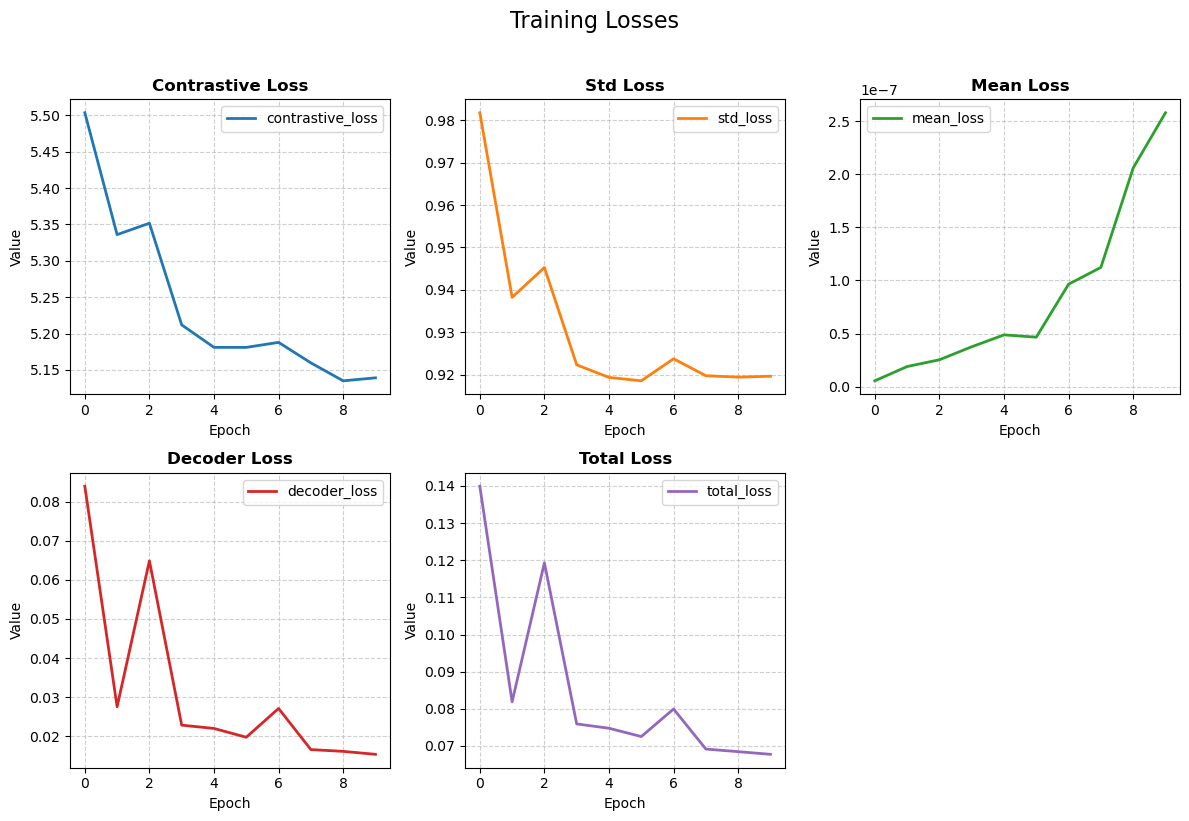

In [7]:
model.plot_epoch_losses()

In [11]:
model.load()

[Manager] Loading and reconstructing model from data/bladder_data/ReverseNetwork/model_new_architecture
[OK] Component reconstructed: LinearBinning
[OK] Component reconstructed: TopPeaksInverseBinner
[OK] Architecture reconstructed: ContrastiveAutoencoderMax_InverseDim
[FAILED] Criterion ContrastiveCriterion not in registry.
[OK] Weights loaded: model_weights.pt
[OK] History loaded (10 epochs)
--- Model Load Complete ---



In [10]:
path_name_npz_file = PATH_DATA / 'ReverseNetwork' / 'mouse_bladder_modified_architecture.npz'
model.SetIMSDataset(dataset)
model.compress_to_file(path_name_npz_file)

[Warning]: Operating on an trained model. IMSDataset, must have set same binner.
[Manager] Binner already exists LinearBinning initialized.
[Model] Encoding image to latent space...


[Model] Done encoding image.
[Model] Compression complete. Saved to: data/bladder_data/ReverseNetwork/mouse_bladder_modified_architecture.npz


In [12]:
path_name_npz_file = PATH_DATA / 'ReverseNetwork' / 'mouse_bladder_modified_architecture.npz'
path_name_imzML_file = PATH_DATA / 'ReverseNetwork' / 'mouse_bladder_modified_architecture_reconstruct'

model.reconstruct_from_file(
    compressed_img_path=path_name_npz_file, 
    output_imzml=path_name_imzML_file)


[Model] Reconstructing image from data/bladder_data/ReverseNetwork/mouse_bladder_modified_architecture.npz...
[Model] Reconstructing 34840 spectra using batch processing...
[  5%] 1792/34840 pixels processed | ETA: 2.8 min
[ 10%] 3584/34840 pixels processed | ETA: 2.6 min
[ 15%] 5376/34840 pixels processed | ETA: 2.5 min
[ 21%] 7168/34840 pixels processed | ETA: 2.5 min
[ 26%] 8960/34840 pixels processed | ETA: 2.3 min
[ 31%] 10752/34840 pixels processed | ETA: 2.1 min
[ 36%] 12544/34840 pixels processed | ETA: 1.9 min
[ 41%] 14336/34840 pixels processed | ETA: 1.8 min
[ 46%] 16128/34840 pixels processed | ETA: 1.6 min
[ 51%] 17920/34840 pixels processed | ETA: 1.5 min
[ 57%] 19712/34840 pixels processed | ETA: 1.4 min
[ 62%] 21504/34840 pixels processed | ETA: 1.2 min
[ 67%] 23296/34840 pixels processed | ETA: 1.0 min
[ 72%] 25088/34840 pixels processed | ETA: 0.9 min
[ 77%] 26880/34840 pixels processed | ETA: 0.7 min
[ 82%] 28672/34840 pixels processed | ETA: 0.6 min
[ 87%] 30464/348

In [ ]:
# original data
PATH_real_data = PATH_DATA / 'bladder_data' / 'mouse_urinary_bladder.imzML'
I_original = m2.ImzMLReader(str(PATH_real_data))

# autoencoded data
PATH_autoencoded_data = Path(str(path_name_imzML_file) + '.imzML')
I_autoencoded =  m2.ImzMLReader(str(PATH_autoencoded_data))



True
!224.615! WARNING: No pixel size found, set x and y spacing to 50 microns!
!228.203! WARNING: Processed profile spectrum is not fully supported! Check the ImzML file.
[229.086] [imzML]: data/bladder_data/bladder_data/mouse_urinary_bladder.imzML
	[pixel size (mm)]: 0.050000x0.050000x0.010000
	[image dimension]: 260x134x1
	[num spectra]: 34840
	[spec. type]: ProcessedProfile
	[mass range]: 400.259620 to 999.795899 with #1500 measurements
!229.089! WARNING: No pixel size found, set x and y spacing to 50 microns!
[229.779] Initialization of the Normalization images took: 2.01587 Average(1 runs):2.01587s
[232.727] [imzML]: data/bladder_data/ReverseNetwork/mouse_bladder_modified_architecture_reconstruct.imzML
	[pixel size (mm)]: 0.050000x0.050000x0.010000
	[image dimension]: 260x134x1
	[num spectra]: 34840
	[spec. type]: ProcessedCentroid
	[mass range]: 400.359410 to 999.048608 with #1483 measurements


In [ ]:
from MSIAutoEncoderWrapper.utils.VisualizationInteractive import M2AIAExplorer, M2AIAMultiExplorer

In [15]:
# r1 = m2.ImzMLReader("sample1.imzML")
# r2 = m2.ImzMLReader("sample2.imzML")
explorer = M2AIAMultiExplorer([I, I_autoencoded], labels=["Original", "Autoencoded"])

In [16]:
explorer.plot()

ValueError: ('Center is out of x-axis range!', np.float64(400.2596199440525), 0.1, <class 'numpy.float32'>, False)